In [19]:
from pathlib import Path
import random, numpy as np, pandas as pd, matplotlib.pyplot as plt


ROOT = Path('/kaggle/input')
SPLIT_SEED = 5
SEED, PHASH_T, COS_T = 42, 6, 0.95   # seed, pHash distance, cosine threshold
random.seed(SEED); np.random.seed(SEED)

def find_one(name):
    # must find exactly one match, otherwise stop
    hits = list(ROOT.rglob(name))
    assert len(hits) == 1, f'{name}: found {len(hits)}'
    return hits[0]

MANIFEST = find_one('manifest_raw.csv')
SUMMARY  = find_one('merge_part_a_summary.json')
CACHE    = find_one('cache512')

n = len(list(CACHE.glob('*.jpg')))
print(MANIFEST); print(SUMMARY); print(CACHE)
print('jpgs:', n)

/kaggle/input/notebooks/syedjaffarrazakazmi/05-oral-merge-and-cache/manifest_raw.csv
/kaggle/input/notebooks/syedjaffarrazakazmi/05-oral-merge-and-cache/merge_part_a_summary.json
/kaggle/input/notebooks/syedjaffarrazakazmi/05-oral-merge-and-cache/cache512
jpgs: 6272


In [2]:

df = pd.read_csv(MANIFEST)
# build full path from the file name only
df['cache_path'] = df['cache_file'].apply(lambda f: str(CACHE / Path(f).name))
df['exists'] = df['cache_path'].apply(lambda p: Path(p).exists())

print('rows:', len(df), '| unique image_id:', df['image_id'].nunique())
print('files found:', df['exists'].sum(), 'of', len(df))
print('eval_ok True:', int(df['eval_ok'].sum()), '| train_ok True:', int(df['train_ok'].sum()))
print(pd.crosstab(df['source'], df['label'], margins=True))

rows: 6272 | unique image_id: 6272
files found: 6272 of 6272
eval_ok True: 5410 | train_ok True: 6245
label       Benign  Healthy  OCA  OPMD   All
source                                      
piyarathne     748      729  129  1394  3000
shivam           0       43   63     0   106
smart_om       178     2119   20   125  2442
zaidpy           0      246  478     0   724
All            926     3137  690  1519  6272


In [3]:
import hashlib

def md5_of(p):
    h = hashlib.md5()
    with open(p, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 20), b''):
            h.update(chunk)
    return h.hexdigest()

df['md5'] = df['cache_path'].apply(md5_of)
sizes = df.groupby('md5')['image_id'].transform('count')
df['md5_group_size'] = sizes
dups = df[sizes > 1].sort_values(['md5', 'image_id'])

print('unique md5:', df['md5'].nunique(), 'of', len(df))
print('photos in exact-duplicate groups:', len(dups), '| groups:', dups['md5'].nunique())
if len(dups):
    g = dups.groupby('md5').agg(n=('image_id', 'count'),
        sources=('source', lambda s: '+'.join(sorted(s))),
        labels=('label', lambda s: '+'.join(sorted(set(s)))))
    print(g['sources'].value_counts().to_string())
    print('groups with mixed labels:', int((g['labels'].str.contains(r'\+')).sum()))
    print(dups[['image_id', 'source', 'label', 'md5']].head(20).to_string(index=False))

unique md5: 6193 of 6272
photos in exact-duplicate groups: 158 | groups: 79
sources
shivam+zaidpy            66
piyarathne+piyarathne    12
zaidpy+zaidpy             1
groups with mixed labels: 0
                image_id source   label                              md5
shivam__00faf28779e8cd3e shivam     OCA 02252b0e249c94a3b808806a0d04c421
          zaidpy__04__45 zaidpy     OCA 02252b0e249c94a3b808806a0d04c421
shivam__305170e49b00db2c shivam     OCA 09feecacd5c4c7cf80a8b4b3c0ccff51
          zaidpy__04__81 zaidpy     OCA 09feecacd5c4c7cf80a8b4b3c0ccff51
shivam__1ec6d52494fab85f shivam     OCA 0ebeb9c0cd8f54c74aadc40858ffb19b
          zaidpy__04__88 zaidpy     OCA 0ebeb9c0cd8f54c74aadc40858ffb19b
shivam__6b33a7cf63d20076 shivam     OCA 169e603b80bb62f99f65300e61330e32
          zaidpy__04__65 zaidpy     OCA 169e603b80bb62f99f65300e61330e32
shivam__7a06c6fcce87d5dd shivam     OCA 1d8a5ff5018c77d33ae55952113975bc
         zaidpy__04__105 zaidpy     OCA 1d8a5ff5018c77d33ae55952113975bc
s

In [4]:
dups = dups.copy()
dups['grp_sources'] = dups.groupby('md5')['source'].transform(lambda s: '+'.join(sorted(s)))

# 1) Piyarathne pairs: same patient or different?
py = dups[dups['grp_sources'] == 'piyarathne+piyarathne']
t = py.groupby('md5').agg(n_patients=('patient_uid', 'nunique'),
                          labels=('label', lambda s: '+'.join(sorted(s))),
                          eval_ok=('eval_ok', 'sum'))
print('Piyarathne pairs:', len(t))
print('  same patient:', int((t.n_patients == 1).sum()), '| different patients:', int((t.n_patients > 1).sum()))
print(t.to_string())

# 2) Shivam photos that are copies of zaidpy, by label
sv = df[df['source'] == 'shivam'].copy()
sv['dup_of_zaidpy'] = sv['md5'].isin(dups[dups['grp_sources'] == 'shivam+zaidpy']['md5'])
print(pd.crosstab(sv['label'], sv['dup_of_zaidpy'], margins=True))

Piyarathne pairs: 12
  same patient: 1 | different patients: 11
                                  n_patients           labels  eval_ok
md5                                                                   
70bf4916ac319431e562a04fa950c558           2  Healthy+Healthy        2
80ba8a451424d25cca4bbbbfc2460734           2  Healthy+Healthy        2
88ae26449a031dfd0a47a97ecdec68e6           2  Healthy+Healthy        2
935b1c6c9522cd5c7e08c9ebb49006d7           2  Healthy+Healthy        2
99b692b08b9556c30711e7cd5f4d455c           2  Healthy+Healthy        2
b9c54f9726d12a8a53fde1a48c8e23d3           2  Healthy+Healthy        2
bee8177921150a5368888f59d2cc53b2           2  Healthy+Healthy        2
cdc2c87464c5cdb0115141087dd4a847           1    Benign+Benign        2
ce40f15bd942ba985f9e44b865037468           2  Healthy+Healthy        2
ced5be15bad136b944bf58d8d758907a           2  Healthy+Healthy        2
d1bdef783ea09fbf80b291a659eaaab3           2  Healthy+Healthy        2
f3b13fbc8a1e6

In [5]:
from PIL import Image
from scipy.fft import dct

def phash64(path):
    im = Image.open(path).convert('L').resize((32, 32), Image.LANCZOS)
    a = np.asarray(im, dtype=np.float64)
    low = dct(dct(a, axis=0, norm='ortho'), axis=1, norm='ortho')[:8, :8]  # 8x8 low frequencies
    bits = (low > np.median(low)).flatten()                               # 64 bits
    return int(''.join('1' if b else '0' for b in bits), 2)

hashes = []
for p in df['cache_path']:
    try:
        hashes.append(phash64(p))
    except Exception as e:
        hashes.append(None); print('FAILED', p, e)
df['phash'] = hashes
H = np.array([h if h is not None else 0 for h in hashes], dtype=np.uint64)

print('missing hashes:', df['phash'].isna().sum(), '| unique hashes:', df['phash'].nunique(), 'of', len(df))
multi = df.groupby('md5')['phash'].transform('nunique') > 1
print('md5 groups with different hashes (should be 0):', int(multi.sum()))

missing hashes: 0 | unique hashes: 6176 of 6272
md5 groups with different hashes (should be 0): 0


In [6]:

POP = np.array([bin(i).count('1') for i in range(256)], dtype=np.uint8)  # bit counts 0..255
rows, cols, dist = [], [], []
CH = 500
for s in range(0, len(H), CH):
    x = H[s:s+CH, None] ^ H[None, :]                             # XOR with all hashes
    d = POP[x.view(np.uint8).reshape(x.shape + (8,))].sum(-1)    # Hamming distance
    r, c = np.nonzero(d <= PHASH_T)
    keep = (r + s) < c                                           # each pair once, no self pairs
    rows += list(r[keep] + s); cols += list(c[keep]); dist += list(d[r[keep], c[keep]])

pairs = pd.DataFrame({'i': rows, 'j': cols, 'dist': dist})
a, b = df.iloc[pairs.i].reset_index(drop=True), df.iloc[pairs.j].reset_index(drop=True)
pairs['id_a'], pairs['id_b'] = a.image_id.values, b.image_id.values
pairs['src'] = ['+'.join(sorted(t)) for t in zip(a.source, b.source)]
pairs['same_md5'] = (a.md5 == b.md5).values
pairs['label_mismatch'] = (a.label != b.label).values
pairs['same_patient'] = (a.patient_uid == b.patient_uid).values

print('pairs with dist <=', PHASH_T, ':', len(pairs), '| exact md5 pairs:', int(pairs.same_md5.sum()))
print(pairs.dist.value_counts().sort_index().to_string())
print(pairs.groupby('src').agg(n=('dist', 'size'),
      new_vs_md5=('same_md5', lambda s: int((~s).sum())),
      label_mismatch=('label_mismatch', 'sum'),
      diff_patient=('same_patient', lambda s: int((~s).sum()))).to_string())
print(pairs.sort_values('dist').head(8)[['id_a', 'id_b', 'dist']].to_string(index=False))

pairs with dist <= 6 : 188 | exact md5 pairs: 79
dist
0    113
2      7
4     15
6     53
                        n  new_vs_md5  label_mismatch  diff_patient
src                                                                
piyarathne+piyarathne  66          54              28            51
shivam+shivam           4           4               0             4
shivam+zaidpy          76          10               0            76
smart_om+smart_om      14          14               1            13
zaidpy+zaidpy          28          27               0             1
                id_a                 id_b  dist
 piyarathne__S-46-04  piyarathne__S-46-05     0
piyarathne__C-20-5-5 piyarathne__C-33-5-4     0
piyarathne__C-20-7-1 piyarathne__C-33-7-1     0
piyarathne__C-20-6-6 piyarathne__C-33-6-5     0
piyarathne__C-20-8-8 piyarathne__C-33-8-7     0
piyarathne__C-20-8-7 piyarathne__C-33-8-6     0
piyarathne__C-21-4-4 piyarathne__C-34-4-4     0
piyarathne__C-20-7-2 piyarathne__C-33-7-2     0


label-mismatch pairs: 29
                     id_a label_a               pat_a                      id_b label_b               pat_b  dist
      piyarathne__R-36-02  Benign     piyarathne_R-36      piyarathne__R-102-02 Healthy    piyarathne_R-102     4
     piyarathne__S-143-02    OPMD    piyarathne_S-143      piyarathne__S-154-01 Healthy    piyarathne_S-154     4
     piyarathne__R-121-03  Benign    piyarathne_R-121      piyarathne__N-266-05    OPMD    piyarathne_N-266     4
     piyarathne__R-144-02 Healthy    piyarathne_R-144      piyarathne__N-299-06  Benign    piyarathne_N-299     4
     piyarathne__N-263-02  Benign    piyarathne_N-263      piyarathne__N-271-03 Healthy    piyarathne_N-271     4
smart_om_286de361e7238064 Healthy smart_om_SMITA00045 smart_om_52d06063e775c5c9  Benign smart_om_SMITA00045     4
     piyarathne__R-210-02  Benign    piyarathne_R-210      piyarathne__N-266-03    OPMD    piyarathne_N-266     4
      piyarathne__R-16-02    OPMD     piyarathne_R-16      piya

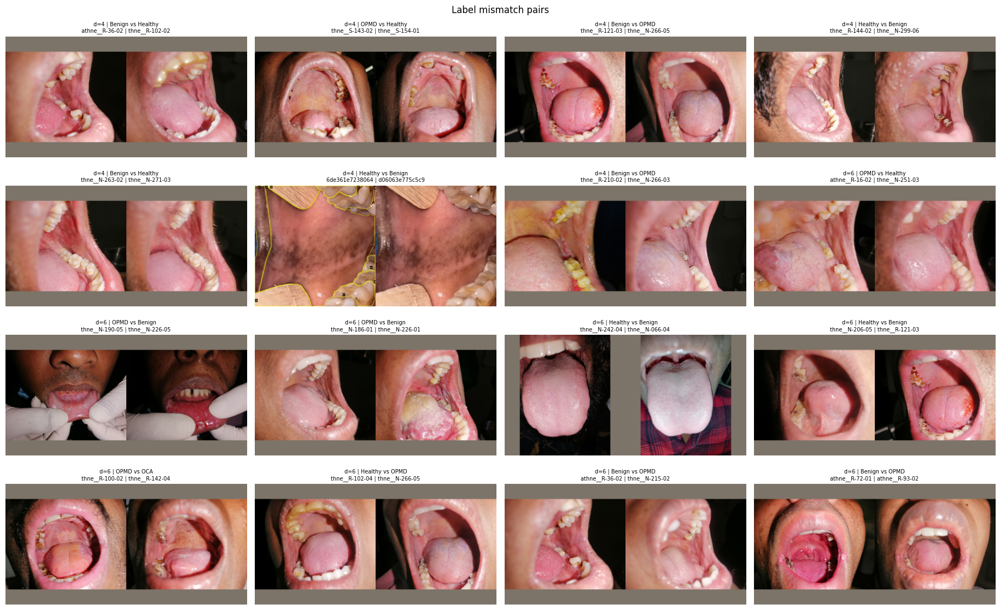

dist-6 non-md5 pairs: 53


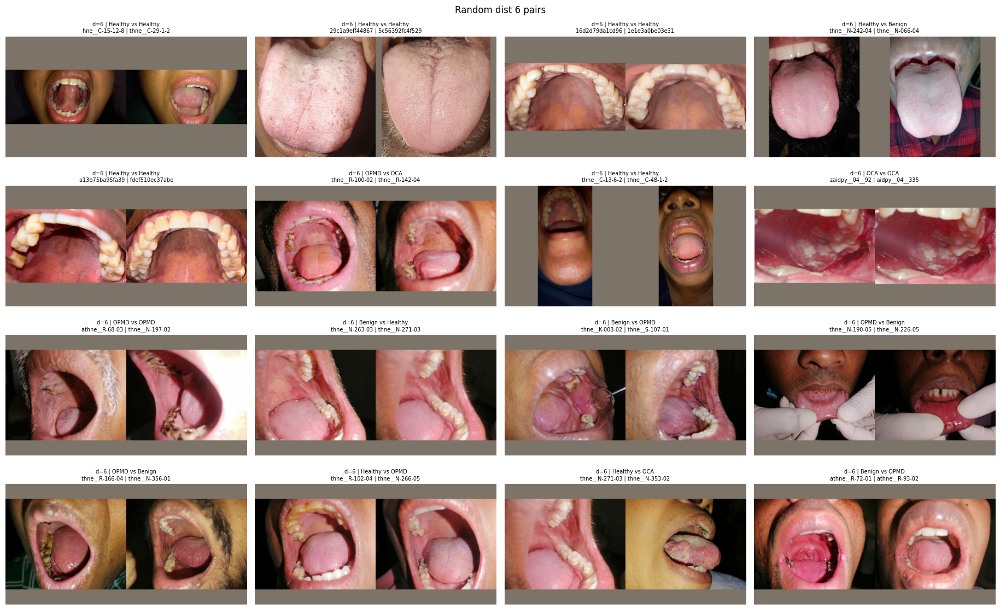

In [7]:

a, b = df.iloc[pairs.i].reset_index(drop=True), df.iloc[pairs.j].reset_index(drop=True)
pairs['label_a'], pairs['label_b'] = a.label.values, b.label.values
pairs['pat_a'], pairs['pat_b'] = a.patient_uid.values, b.patient_uid.values

def thumb(p, s=224):
    im = Image.open(p).convert('RGB'); im.thumbnail((s, s))
    c = Image.new('RGB', (s, s), (124, 116, 104))
    c.paste(im, ((s - im.width)//2, (s - im.height)//2)); return c

def show_pairs(sub, title, ncol=4, maxn=16):
    sub = sub.head(maxn); nrow = max(1, -(-len(sub)//ncol))
    fig, axs = plt.subplots(nrow, ncol, figsize=(4.6*ncol, 2.9*nrow), squeeze=False)
    for ax in axs.ravel(): ax.axis('off')
    for ax, (_, r) in zip(axs.ravel(), sub.iterrows()):
        both = Image.new('RGB', (448, 224))
        both.paste(thumb(df.cache_path[r.i]), (0, 0)); both.paste(thumb(df.cache_path[r.j]), (224, 0))
        ax.imshow(both)
        ax.set_title(f'd={r.dist} | {r.label_a} vs {r.label_b}\n{r.id_a[-14:]} | {r.id_b[-14:]}', fontsize=7)
    fig.suptitle(title); plt.tight_layout(); plt.show()

mm = pairs[pairs.label_mismatch].sort_values('dist')
print('label-mismatch pairs:', len(mm))
print(mm[['id_a','label_a','pat_a','id_b','label_b','pat_b','dist']].to_string(index=False))
show_pairs(mm, 'Label mismatch pairs')

rs = pairs[(pairs.dist == 6) & (~pairs.same_md5)].sample(frac=1, random_state=42)
print('dist-6 non-md5 pairs:', len(rs))
show_pairs(rs, 'Random dist 6 pairs')

dist 2 pairs: 7
src
piyarathne+piyarathne    4
zaidpy+zaidpy            2
shivam+zaidpy            1
dist 0 non-md5 pairs: 34
src
zaidpy+zaidpy    22
shivam+zaidpy     8
shivam+shivam     4


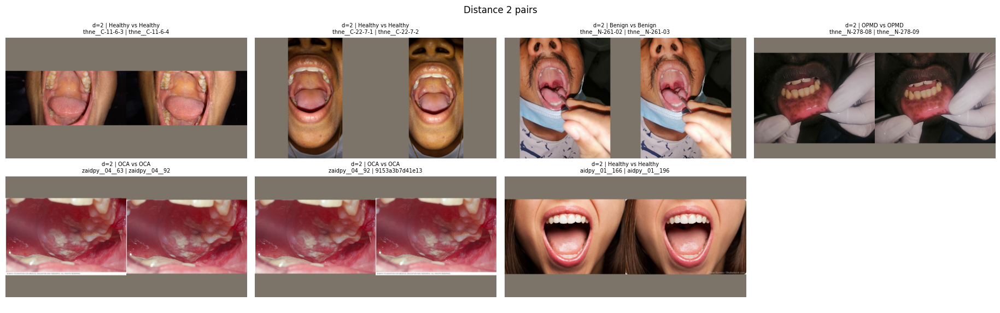

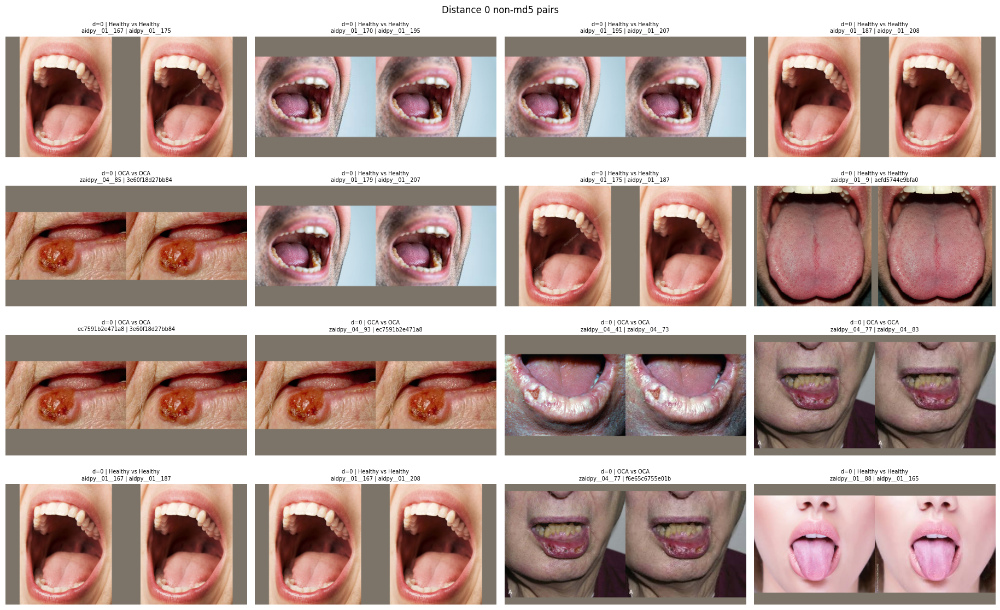

In [8]:
PHASH_T = 2   # new threshold, replaces 6

d2 = pairs[pairs.dist == 2]
d0 = pairs[(pairs.dist == 0) & (~pairs.same_md5)]
print('dist 2 pairs:', len(d2)); print(d2.src.value_counts().to_string())
print('dist 0 non-md5 pairs:', len(d0)); print(d0.src.value_counts().to_string())

show_pairs(d2, 'Distance 2 pairs')
show_pairs(d0.sample(frac=1, random_state=42), 'Distance 0 non-md5 pairs')

In [9]:
import torch, torch.nn as nn, torchvision, time
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T

dev = 'cuda' if torch.cuda.is_available() else 'cpu'
w = torchvision.models.ViT_B_16_Weights.IMAGENET1K_V1
model = torchvision.models.vit_b_16(weights=w)
model.heads = nn.Identity()            # keep the 768-d CLS feature
model.eval().to(dev)

# full image resized to 224 (no crop), ImageNet normalisation
tf = T.Compose([T.Resize((224, 224)), T.ToTensor(),
                T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

class DS(Dataset):
    def __init__(self, paths): self.paths = list(paths)
    def __len__(self): return len(self.paths)
    def __getitem__(self, k): return tf(Image.open(self.paths[k]).convert('RGB'))

dl = DataLoader(DS(df['cache_path']), batch_size=64, shuffle=False, num_workers=2)
t0, feats = time.time(), []
with torch.no_grad():
    for x in dl:
        with torch.autocast(device_type='cuda', enabled=(dev == 'cuda')):
            f = model(x.to(dev))
        feats.append(f.float().cpu())
E = torch.cat(feats).numpy()
E = E / np.linalg.norm(E, axis=1, keepdims=True)   # L2 normalise, so dot product = cosine
np.save('/kaggle/working/emb_vitb16.npy', E)

m = pairs[pairs.same_md5]
cos = (E[m.i.values] * E[m.j.values]).sum(1)
print('device:', dev, '| seconds:', round(time.time() - t0))
print('shape:', E.shape, '| NaN:', int(np.isnan(E).sum()))
print('norm min/max:', np.linalg.norm(E, axis=1).min().round(4), np.linalg.norm(E, axis=1).max().round(4))
print('md5 pairs cosine min/mean:', cos.min().round(4), cos.mean().round(4))

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 236MB/s] 


device: cuda | seconds: 27
shape: (6272, 768) | NaN: 0
norm min/max: 1.0 1.0
md5 pairs cosine min/mean: 1.0 1.0


In [10]:
N = len(E)
lab = df['label'].astype('category').cat.codes.values
TH = np.array([0.90, 0.92, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99])

known = pairs[pairs.dist <= 2]                      # md5 + pHash<=2 pairs (120)
known_keys = np.sort(known.i.values.astype(np.int64) * N + known.j.values)
known_cos = (E[known.i.values] * E[known.j.values]).sum(1)

cnt = np.zeros(len(TH), int); new = np.zeros(len(TH), int); mm = np.zeros(len(TH), int)
keep_i, keep_j, keep_s = [], [], []
for s in range(0, N, 1000):
    S = E[s:s+1000] @ E.T                            # cosine, rows are L2-normalised
    r, c = np.nonzero(S >= TH[0])
    r = r + s
    ok = r < c                                       # each pair once, no self pairs
    r, c = r[ok], c[ok]
    sims = S[r - s, c]
    is_known = np.isin(r.astype(np.int64) * N + c, known_keys)
    diff = lab[r] != lab[c]
    for k, t in enumerate(TH):
        m = sims >= t
        cnt[k] += m.sum(); new[k] += (m & ~is_known).sum(); mm[k] += (m & diff).sum()
    m = sims >= COS_T
    keep_i.append(r[m]); keep_j.append(c[m]); keep_s.append(sims[m])

epairs = pd.DataFrame({'i': np.concatenate(keep_i), 'j': np.concatenate(keep_j),
                       'cos': np.concatenate(keep_s)})
tab = pd.DataFrame({'cos>=': TH, 'pairs': cnt, 'not_known': new, 'label_mismatch': mm,
                    'mismatch_%': (100 * mm / np.maximum(cnt, 1)).round(1),
                    'known_recovered': [int((known_cos >= t).sum()) for t in TH]})
print(tab.to_string(index=False))
print('known pairs:', len(known), '| cosine min / 5th pct / median:',
      known_cos.min().round(4), np.percentile(known_cos, 5).round(4), np.median(known_cos).round(4))
print('stored pairs at cos >=', COS_T, ':', len(epairs))

 cos>=  pairs  not_known  label_mismatch  mismatch_%  known_recovered
  0.90    150         36               2         1.3              114
  0.92    121         15               1         0.8              106
  0.94    105          7               1         1.0               98
  0.95    100          3               0         0.0               97
  0.96     92          0               0         0.0               92
  0.97     91          0               0         0.0               91
  0.98     88          0               0         0.0               88
  0.99     87          0               0         0.0               87
known pairs: 120 | cosine min / 5th pct / median: 0.7843 0.9034 1.0
stored pairs at cos >= 0.95 : 100


new pairs at cos >= 0.90: 36
                     id_a label_a                      id_b label_b   cos
     piyarathne__R-262-03  Benign      piyarathne__R-262-04  Benign 0.957
           zaidpy__04__66     OCA            zaidpy__04__96     OCA 0.956
           zaidpy__04__96     OCA  shivam__eab492fedb09816d     OCA 0.956
     piyarathne__N-261-01  Benign      piyarathne__N-261-07 Healthy 0.950
     piyarathne__C-35-6-2 Healthy      piyarathne__C-35-6-3 Healthy 0.947
     piyarathne__N-261-05  Benign      piyarathne__N-261-06  Benign 0.946
smart_om_919868874e94ef2e    OPMD smart_om_e7969750de0bda2f    OPMD 0.942
          zaidpy__04__442     OCA           zaidpy__04__478     OCA 0.933
           zaidpy__01__13 Healthy            zaidpy__01__43 Healthy 0.931
     piyarathne__C-38-7-7 Healthy      piyarathne__C-38-7-8 Healthy 0.930
          zaidpy__04__335     OCA  shivam__0b9153a3b7d41e13     OCA 0.927
           zaidpy__04__63     OCA           zaidpy__04__335     OCA 0.927
     piya

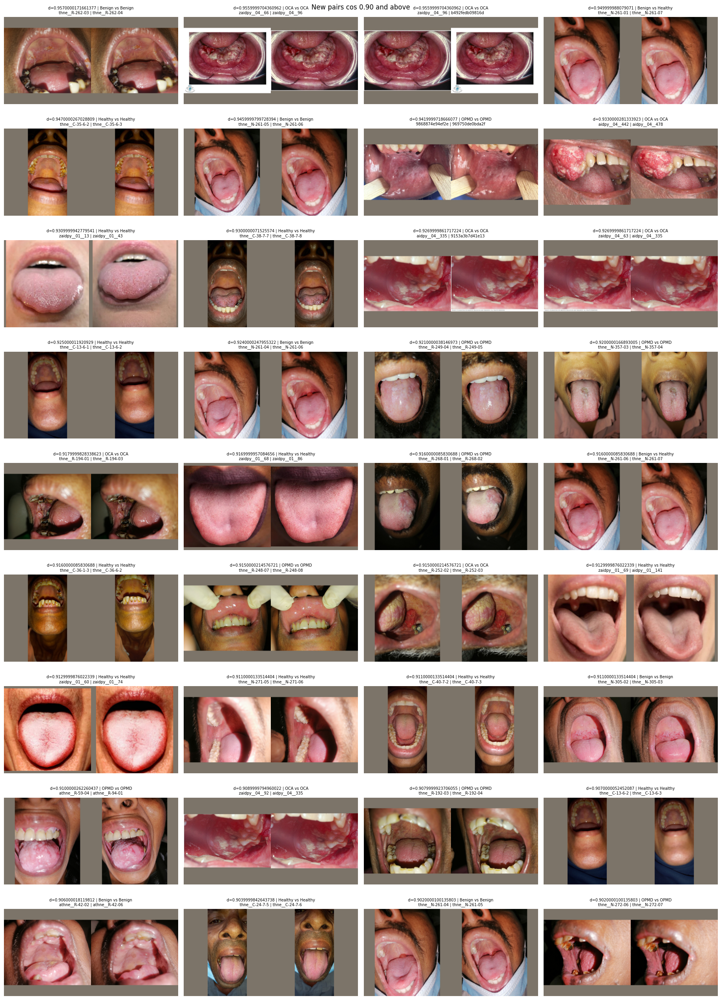

lowest-cosine known pairs: [0.784 0.798 0.889 0.889 0.889 0.889 0.904 0.904 0.912 0.912 0.912 0.912
 0.913 0.914 0.926 0.932]


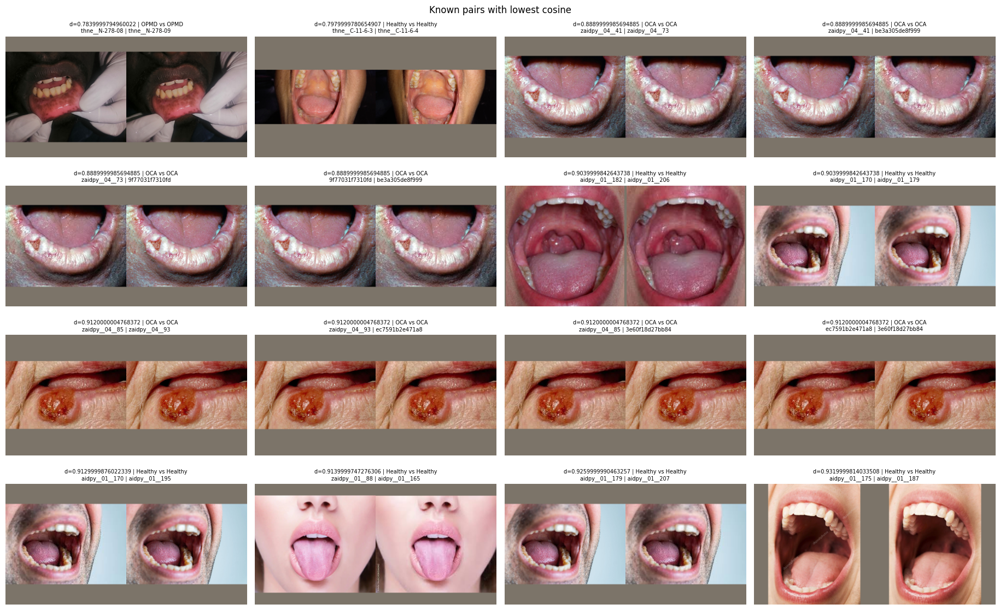

In [11]:
def mk(i, j, sc):
    p = pd.DataFrame({'i': i, 'j': j, 'dist': np.round(sc, 3)})   # 'dist' holds the cosine here
    p['id_a'], p['id_b'] = df.image_id.values[p.i], df.image_id.values[p.j]
    p['label_a'], p['label_b'] = df.label.values[p.i], df.label.values[p.j]
    return p

ri, ci, ss = [], [], []
for s in range(0, N, 1000):
    S = E[s:s+1000] @ E.T
    r, c = np.nonzero(S >= 0.90); r = r + s
    ok = r < c; r, c = r[ok], c[ok]
    ri.append(r); ci.append(c); ss.append(S[r - s, c])
ri, ci, ss = np.concatenate(ri), np.concatenate(ci), np.concatenate(ss)
is_known = np.isin(ri.astype(np.int64) * N + ci, known_keys)

newp = mk(ri[~is_known], ci[~is_known], ss[~is_known]).sort_values('dist', ascending=False)
print('new pairs at cos >= 0.90:', len(newp))
print(newp[['id_a', 'label_a', 'id_b', 'label_b', 'dist']].rename(columns={'dist': 'cos'}).to_string(index=False))
show_pairs(newp, 'New pairs cos 0.90 and above', maxn=40)

kc = (E[known.i.values] * E[known.j.values]).sum(1)
low = mk(known.i.values, known.j.values, kc).sort_values('dist').head(16)
print('lowest-cosine known pairs:', low.dist.values)
show_pairs(low, 'Known pairs with lowest cosine')

In [21]:
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

DROP_T = 2
e = pairs[pairs.dist <= DROP_T]
N = len(df)
g = coo_matrix((np.ones(len(e)), (e.i.values, e.j.values)), shape=(N, N))
n_comp, comp = connected_components(g, directed=False)
df['cluster_id'] = comp
df['cluster_size'] = df.groupby('cluster_id')['image_id'].transform('count')

multi = df[df.cluster_size > 1]
cl = multi.groupby('cluster_id').agg(
    n=('image_id', 'count'),
    sources=('source', lambda s: '+'.join(sorted(s))),
    n_labels=('label', 'nunique'),
    n_patients=('patient_uid', 'nunique'))

print('edges used:', len(e), '| clusters with >1 photo:', len(cl), '| photos in them:', len(multi))
print('cluster size table:'); print(cl.n.value_counts().sort_index().to_string())
print('sources in clusters:'); print(cl.sources.value_counts().to_string())
print('clusters with mixed labels (should be 0):', int((cl.n_labels > 1).sum()))
print('clusters spanning >1 patient:', int((cl.n_patients > 1).sum()))
print(cl[cl.n_patients > 1].sources.value_counts().to_string())
print('photos to mark as duplicates (n-1 per cluster):', int((cl.n - 1).sum()))

edges used: 120 | clusters with >1 photo: 89 | photos in them: 191
cluster size table:
n
2    81
3     3
4     5
sources in clusters:
sources
shivam+zaidpy                  57
piyarathne+piyarathne          16
zaidpy+zaidpy                   8
shivam+shivam+zaidpy+zaidpy     3
shivam+zaidpy+zaidpy            2
zaidpy+zaidpy+zaidpy+zaidpy     2
shivam+shivam+zaidpy            1
clusters with mixed labels (should be 0): 0
clusters spanning >1 patient: 74
sources
shivam+zaidpy                  57
piyarathne+piyarathne          11
shivam+shivam+zaidpy+zaidpy     3
shivam+zaidpy+zaidpy            2
shivam+shivam+zaidpy            1
photos to mark as duplicates (n-1 per cluster): 102


In [13]:
# Rebuild clusters: pHash<=2 pairs plus embedding pairs cos>=0.95
df['cluster_old'] = df['cluster_id']                  # keep the old ids to compare

e1 = pairs[pairs.dist <= DROP_T][['i', 'j']]          # md5 and pHash pairs
e2 = epairs[['i', 'j']]                               # cosine pairs
e = pd.concat([e1, e2]).drop_duplicates()

N = len(df)
g = coo_matrix((np.ones(len(e)), (e.i.values, e.j.values)), shape=(N, N))
n_comp, comp = connected_components(g, directed=False)
df['cluster_id'] = comp
df['cluster_size'] = df.groupby('cluster_id')['image_id'].transform('count')
old_size = df.groupby('cluster_old')['image_id'].transform('count')

multi = df[df.cluster_size > 1]
cl = multi.groupby('cluster_id').agg(
    n=('image_id', 'count'),
    sources=('source', lambda s: '+'.join(sorted(s))),
    n_labels=('label', 'nunique'),
    n_patients=('patient_uid', 'nunique'))

print('edges: pHash', len(e1), '| from cosine only:', len(e) - len(e1), '| total', len(e))
print('clusters >1 photo:', len(cl), '| photos in them:', len(multi), '| mark as dup:', int((cl.n - 1).sum()))
print('mixed labels (should be 0):', int((cl.n_labels > 1).sum()))
print('clusters mixing clinical and web:',
      int(cl.sources.apply(lambda s: bool({'piyarathne', 'smart_om'} & set(s.split('+'))) and bool({'zaidpy', 'shivam'} & set(s.split('+')))).sum()))
print('photos newly in a cluster:'); print(df[(df.cluster_size > 1) & (old_size == 1)][['image_id', 'label', 'cluster_id']].to_string(index=False))

edges: pHash 120 | from cosine only: 3 | total 123
clusters >1 photo: 90 | photos in them: 194 | mark as dup: 104
mixed labels (should be 0): 0
clusters mixing clinical and web: 0
photos newly in a cluster:
            image_id  label  cluster_id
piyarathne__R-262-03 Benign        2536
piyarathne__R-262-04 Benign        2536
      zaidpy__04__96    OCA        5483


In [14]:
# Mark web duplicates: keep ONE photo per cluster, never delete rows
df['drop_reason'] = ''
rank = {'zaidpy': 0, 'shivam': 1}                      # prefer the zaidpy copy
web = df[df.source.isin(rank) & (df.cluster_size > 1)].copy()
web['r'] = web.source.map(rank)
web = web.sort_values(['cluster_id', 'r', 'image_id'])
keep = web.groupby('cluster_id').head(1)               # first row per cluster = kept
kept_id = keep.set_index('cluster_id')['image_id']
drop = web.drop(keep.index)
df.loc[drop.index, 'drop_reason'] = 'web_duplicate_of_' + drop['cluster_id'].map(kept_id)

# log file
log = drop[['image_id', 'source', 'label', 'cluster_id']].assign(kept_id=drop['cluster_id'].map(kept_id).values)
log.to_csv('/kaggle/working/dedup_log.csv', index=False)

# checks
assert df.loc[df.drop_reason != '', 'source'].isin(['zaidpy', 'shivam']).all()   # no clinical drops
assert (df.loc[drop.index, 'label'].values == df.set_index('image_id').loc[log.kept_id, 'label'].values).all()  # same label as kept copy
nc = df[df.cluster_size > 1].groupby('cluster_id')['source'].apply(lambda s: s.isin(['piyarathne', 'smart_om']).any())
print('clinical clusters (not dropped):', int(nc.sum()), '| web clusters:', int((~nc).sum()))
print('rows dropped:', len(drop), '| rows kept:', int((df.drop_reason == '').sum()))
print('dropped by source:', drop.source.value_counts().to_dict())
print(pd.crosstab(df.loc[df.drop_reason == '', 'source'], df.loc[df.drop_reason == '', 'label'], margins=True))

clinical clusters (not dropped): 17 | web clusters: 73
rows dropped: 87 | rows kept: 6185
dropped by source: {'shivam': 67, 'zaidpy': 20}
label       Benign  Healthy  OCA  OPMD   All
source                                      
piyarathne     748      729  129  1394  3000
shivam           0       32    7     0    39
smart_om       178     2119   20   125  2442
zaidpy           0      233  471     0   704
All            926     3113  627  1519  6185


In [15]:
# group_id: union-find over patient_uid, linked by duplicate clusters
clin = ['piyarathne', 'smart_om']
parent = {u: u for u in df['patient_uid'].unique()}
def find(u):
    while parent[u] != u:
        parent[u] = parent[parent[u]]; u = parent[u]
    return u
def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb: parent[rb] = ra

# 1) patients that share a duplicate cluster (dropped rows still count)
for _, s in df[df.cluster_size > 1].groupby('cluster_id')['patient_uid']:
    u = s.unique()
    for x in u[1:]: union(u[0], x)

# 2) clinical near-duplicates (cos 0.90+) across different patients
n_extra = 0
for i, j in zip(newp.i.values, newp.j.values):
    a, b = df.iloc[i], df.iloc[j]
    if a.source in clin and b.source in clin and a.patient_uid != b.patient_uid:
        union(a.patient_uid, b.patient_uid); n_extra += 1

code = pd.factorize(df['patient_uid'].map(find))[0]
df['group_id'] = ['g%04d' % c for c in code]

gs = df.groupby('group_id').agg(n_pat=('patient_uid', 'nunique'), n_img=('image_id', 'count'),
        srcs=('source', lambda s: '+'.join(sorted(set(s)))))
print('patients (uid):', df.patient_uid.nunique(), '| groups:', df.group_id.nunique(), '| extra cosine links:', n_extra)
print(gs.srcs.value_counts().to_string())
print('clinical groups with >1 patient:', int(((gs.n_pat > 1) & gs.srcs.isin(clin)).sum()))
print(gs[(gs.n_pat > 1) & gs.srcs.isin(clin)].sort_values('n_pat', ascending=False).head(15).to_string())
print('unassigned rows:', int(df.group_id.isna().sum()))

patients (uid): 1849 | groups: 1778 | extra cosine links: 1
srcs
piyarathne       711
zaidpy           636
smart_om         329
shivam+zaidpy     63
shivam            39
clinical groups with >1 patient: 3
          n_pat  n_img        srcs
group_id                          
g0056         2     14  piyarathne
g0408         2     15  piyarathne
g0409         2     10  piyarathne
unassigned rows: 0


In [23]:
# reset what the first run of cells 12 and 13 wrote
print(df.drop_reason.value_counts().to_dict())   # before reset
df.loc[df.drop_reason.isin(['test_group_not_eval_ok', 'label_conflict']), 'drop_reason'] = ''
print(df.drop_reason.value_counts().to_dict())   # after reset

{'': 6185, 'web_duplicate_of_zaidpy__04__41': 3, 'web_duplicate_of_zaidpy__04__77': 3, 'web_duplicate_of_zaidpy__04__85': 3, 'web_duplicate_of_zaidpy__01__167': 3, 'web_duplicate_of_zaidpy__01__170': 3, 'web_duplicate_of_zaidpy__04__63': 2, 'web_duplicate_of_zaidpy__04__66': 2, 'web_duplicate_of_zaidpy__01__9': 2, 'web_duplicate_of_zaidpy__04__199': 2, 'web_duplicate_of_zaidpy__01__165': 1, 'web_duplicate_of_zaidpy__04__445': 1, 'web_duplicate_of_zaidpy__01__182': 1, 'web_duplicate_of_zaidpy__01__166': 1, 'web_duplicate_of_zaidpy__01__200': 1, 'web_duplicate_of_zaidpy__01__202': 1, 'web_duplicate_of_zaidpy__01__133': 1, 'web_duplicate_of_zaidpy__01__149': 1, 'web_duplicate_of_zaidpy__04__13': 1, 'web_duplicate_of_zaidpy__04__25': 1, 'web_duplicate_of_zaidpy__04__27': 1, 'web_duplicate_of_zaidpy__04__29': 1, 'web_duplicate_of_zaidpy__04__30': 1, 'web_duplicate_of_zaidpy__04__31': 1, 'web_duplicate_of_zaidpy__04__37': 1, 'web_duplicate_of_zaidpy__04__6': 1, 'web_duplicate_of_zaidpy__04__

In [18]:
# Cell 14 (seed search): which seed gives the most even test split? Uses labels only, no model.
from sklearn.model_selection import StratifiedGroupKFold
clin = ['piyarathne', 'smart_om']
el = df[df.source.isin(clin) & df.eval_ok].copy()
assert len(el) == 5410, len(el)                       # same pool as cell 12
el['strat'] = el.label + '|' + el.source
tot = el.groupby(['source', 'label']).size()          # 8 cells

rows = []
for s in range(100):
    sgk = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=s)
    _, te_i = next(iter(sgk.split(el, el.strat, groups=el.group_id)))
    tt = el.iloc[te_i]
    pct = 100 * tt.groupby(["source", "label"]).size().reindex(tot.index, fill_value=0) / tot
    oca = tt[tt.label == 'OCA']
    rows.append(dict(seed=s, test_n=len(tt),
                     max_dev=round((pct - 20).abs().max(), 1),         # worst cell vs 20%
                     smom_OPMD=int(((tt.source == 'smart_om') & (tt.label == 'OPMD')).sum()),
                     smom_OCA=int(((tt.source == 'smart_om') & (tt.label == 'OCA')).sum()),
                     OCA_photos=len(oca), OCA_groups=oca.group_id.nunique()))
res = pd.DataFrame(rows).sort_values('max_dev')
print('seed 42 (current):'); print(res[res.seed == 42].to_string(index=False))
print('\nbest 10 by max_dev:'); print(res.head(10).to_string(index=False))

seed 42 (current):
 seed  test_n  max_dev  smom_OPMD  smom_OCA  OCA_photos  OCA_groups
   42    1100     13.5          7         3          29          14

best 10 by max_dev:
 seed  test_n  max_dev  smom_OPMD  smom_OCA  OCA_photos  OCA_groups
    5    1128      2.9         22         4          26          16
   32    1104      3.1         25         4          30          14
    0    1104      3.7         23         4          25          12
   59    1027      3.9         21         4          34          17
   20    1060      4.5         19         4          28          16
   74    1067      4.8         22         4          36          18
   40    1042      5.0         25         5          28          15
   56    1050      5.0         22         3          29          16
   91    1058      5.0         21         5          27          17
   77    1010      5.0         26         5          27          19


In [24]:
from sklearn.model_selection import StratifiedGroupKFold

# Eligible for test: clinical, eval_ok, not dropped
clin = ['piyarathne', 'smart_om']
df['split'] = ''
el = df[df.source.isin(clin) & df.eval_ok & (df.drop_reason == '')].copy()
el['strat'] = el.label + '|' + el.source               # stratify by label and source

# 5 folds by group, first fold = test (about 20%)
sgk = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SPLIT_SEED)
tr_i, te_i = next(iter(sgk.split(el, el.strat, groups=el.group_id)))
df.loc[el.index[te_i], 'split'] = 'test'

# other rows of a test group (not eval_ok) must not go to training
tg = set(df.loc[df.split == 'test', 'group_id'])
x = df[df.group_id.isin(tg) & (df.split != 'test')]
df.loc[x.index, 'split'] = 'excluded'
df.loc[x.index, 'drop_reason'] = 'test_group_not_eval_ok'

# checks
el['split'] = df.loc[el.index, 'split']
assert set(el.loc[el.split == 'test', 'group_id']).isdisjoint(el.loc[el.split != 'test', 'group_id'])
assert df.loc[df.split == 'test', 'eval_ok'].all()
assert df.loc[df.split == 'test', 'source'].isin(clin).all()

tab = el.groupby(['source', 'label']).size().rename('eligible').to_frame()
tab['test'] = el[el.split == 'test'].groupby(['source', 'label']).size()
tab = tab.fillna(0).astype(int); tab['test_%'] = (100 * tab.test / tab.eligible).round(1)
print('eligible photos:', len(el), '| groups:', el.group_id.nunique())
print('test photos:', int((el.split == 'test').sum()), '| test groups:', len(tg),
      '| share:', round(100 * (el.split == 'test').mean(), 1), '%')
print(tab.to_string())
oca = el[el.label == 'OCA']
print('OCA test: photos', int((oca.split == 'test').sum()), '| groups', oca.loc[oca.split == 'test', 'group_id'].nunique(),
      '| of all OCA groups', oca.group_id.nunique())
print('Variation photos in test:', int(((el.split == 'test') & el.is_variation).sum()), 'of', int(el.is_variation.sum()))
print('excluded rows (test groups, not eval_ok):', len(x))

eligible photos: 5410 | groups: 1040
test photos: 1128 | test groups: 210 | share: 20.9 %
                    eligible  test  test_%
source     label                          
piyarathne Benign        748   151    20.2
           Healthy       729   138    18.9
           OCA           129    22    17.1
           OPMD         1393   276    19.8
smart_om   Benign        168    38    22.6
           Healthy      2115   477    22.6
           OCA            20     4    20.0
           OPMD          108    22    20.4
OCA test: photos 26 | groups 16 | of all OCA groups 79
Variation photos in test: 38 of 168
excluded rows (test groups, not eval_ok): 7


In [25]:
# 1) freeze the test set (never edit after this)
df.loc[df.split == 'test', ['image_id', 'group_id', 'label', 'source']].to_csv('/kaggle/working/test_ids.csv', index=False)

# 2) dev folds: clinical, eval_ok, not test, not dropped
df['fold'] = -1
pool = df[df.source.isin(clin) & df.eval_ok & (df.drop_reason == '') & (df.split == '')].copy()
pool['strat'] = pool.label + '|' + pool.source
sgk = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SPLIT_SEED)
for k, (_, t) in enumerate(sgk.split(pool, pool.strat, groups=pool.group_id)):
    df.loc[pool.index[t], 'fold'] = k

# 3) other clinical rows (not eval_ok) follow their group; label conflicts are dropped
gfold = df[df.fold >= 0].groupby('group_id')['fold'].first()
rest = df[df.source.isin(clin) & (df.split == '') & (df.fold == -1)]
bad = rest[~rest.train_ok]
df.loc[bad.index, ['split', 'drop_reason']] = ['dropped', 'label_conflict']
ok = rest[rest.train_ok]
df.loc[ok.index, 'fold'] = ok.group_id.map(gfold).fillna(-1).astype(int)

# 4) split names: fold 0 = val, folds 1-4 = train, web = train, drops = dropped
m = df.source.isin(clin) & (df.split == '') & (df.drop_reason == '')
df.loc[m, 'split'] = np.where(df.loc[m, 'fold'] == 0, 'val', 'train')
df.loc[df.source.isin(['zaidpy', 'shivam']) & (df.drop_reason == ''), 'split'] = 'train'
df.loc[(df.drop_reason != '') & (df.split != 'test'), 'split'] = 'dropped'

# checks
assert (df.split != '').all()
assert (df[df.fold >= 0].groupby('group_id')['fold'].nunique() == 1).all()
gs = df[df.split.isin(['train', 'val', 'test'])].groupby('group_id')['split'].nunique()
assert (gs == 1).all()
assert df[df.split.isin(['train', 'val'])].train_ok.all()

print(df.split.value_counts().to_dict())
print(pd.crosstab(df.split, df.source))
dv = df.loc[pool.index]
print(pd.crosstab(dv.fold, dv.label, margins=True))
print('OCA groups per fold:', dv[dv.label == 'OCA'].groupby('fold').group_id.nunique().to_dict())
print(dv[(dv.source == 'smart_om') & dv.label.isin(['OCA', 'OPMD'])].groupby(['fold', 'label']).size().unstack(fill_value=0))

{'train': 4169, 'test': 1128, 'val': 861, 'dropped': 114}
source   piyarathne  shivam  smart_om  zaidpy
split                                        
dropped           0      67        27      20
test            587       0       541       0
train          1896      39      1530     704
val             517       0       344       0
label  Benign  Healthy  OCA  OPMD   All
fold                                   
0         158      421   32   250   861
1         133      475   22   247   877
2         123      472   19   222   836
3         141      452   14   267   874
4         172      409   36   217   834
All       727     2229  123  1203  4282
OCA groups per fold: {0: 17, 1: 10, 2: 11, 3: 11, 4: 14}
label  OCA  OPMD
fold            
0        1    18
1        2    24
2        5    15
3        3    17
4        5    12


In [26]:
# Cell 14: leakage checks. All checks run, then it stops if any failed.
TEST_CSV = '/kaggle/working/test_ids.csv'
kept = df[df.split.isin(['train', 'val', 'test'])]
te, va, tr = (kept[kept.split == s] for s in ['test', 'val', 'train'])
results = []
def check(name, ok, detail=''):
    results.append(bool(ok)); print('PASS' if ok else 'FAIL', '|', name, detail)

def spans(col):
    # how many values of `col` appear in more than one split (kept rows only)
    return int((kept.groupby(col)['split'].nunique() > 1).sum())

check('rows = 6272', len(df) == 6272, len(df))
check('split names valid', set(df.split) <= {'train', 'val', 'test', 'dropped'}, sorted(set(df.split)))
for col in ['group_id', 'cluster_id', 'md5']:
    check(f'{col} not shared across splits', spans(col) == 0, f'(shared: {spans(col)})')
check('test: clinical only', te.source.isin(clin).all())
check('test: eval_ok True', te.eval_ok.all())
check('test: fold = -1', (te.fold == -1).all())
check('val: clinical only', va.source.isin(clin).all())
check('val: fold = 0', (va.fold == 0).all())
check('train: train_ok True', tr.train_ok.all())
check('train clinical rows: fold != 0', (tr[tr.source.isin(clin)].fold != 0).all())
check('web rows only in train', kept[~kept.source.isin(clin)].split.eq('train').all())
check('kept rows have no drop_reason', (kept.drop_reason == '').all())
check('dropped rows all have drop_reason', (df[df.split == 'dropped'].drop_reason != '').all())
saved = pd.read_csv(TEST_CSV)
check('test_ids.csv matches test split', len(saved) == len(te) and set(saved.image_id) == set(te.image_id))

print('\nsplit counts:', df.split.value_counts().to_dict())
print('val rows with eval_ok False:', int((~va.eval_ok).sum()))
d = df[df.split == 'dropped']
print(pd.crosstab(d.drop_reason, d.source, margins=True))
assert all(results), 'at least one check failed, see FAIL lines above'
print('\nALL CHECKS PASSED')

PASS | rows = 6272 6272
PASS | split names valid ['dropped', 'test', 'train', 'val']
PASS | group_id not shared across splits (shared: 0)
PASS | cluster_id not shared across splits (shared: 0)
PASS | md5 not shared across splits (shared: 0)
PASS | test: clinical only 
PASS | test: eval_ok True 
PASS | test: fold = -1 
PASS | val: clinical only 
PASS | val: fold = 0 
PASS | train: train_ok True 
PASS | train clinical rows: fold != 0 
PASS | web rows only in train 
PASS | kept rows have no drop_reason 
PASS | dropped rows all have drop_reason 
PASS | test_ids.csv matches test split 

split counts: {'train': 4169, 'test': 1128, 'val': 861, 'dropped': 114}
val rows with eval_ok False: 0
source                            shivam  smart_om  zaidpy  All
drop_reason                                                    
label_conflict                         0        20       0   20
test_group_not_eval_ok                 0         7       0    7
web_duplicate_of_zaidpy__01__133       0         0  

In [27]:
# Cell 15: split report and splits_summary.json
import json
OUT = '/kaggle/working/splits_summary.json'
kept = df[df.split.isin(['train', 'val', 'test'])]
order = ['train', 'val', 'test']

# 1) photos: split x source x label
print('PHOTOS'); print(pd.crosstab([kept.split, kept.source], kept.label, margins=True))

# 2) groups and patients per split (a group can hold several labels, so labels overlap)
grp = kept.groupby('split').agg(photos=('image_id', 'count'), groups=('group_id', 'nunique'),
                                patients=('patient_uid', 'nunique')).reindex(order)
print('\nGROUPS AND PATIENTS PER SPLIT'); print(grp)
assert grp.groups.sum() == kept.group_id.nunique()        # no group in two splits
assert grp.patients.sum() == kept.patient_uid.nunique()   # no patient in two splits

# 3) groups per split and label
gl = kept.groupby(['split', 'label']).group_id.nunique().unstack(fill_value=0).reindex(order)
print('\nGROUPS PER SPLIT AND LABEL (labels overlap)'); print(gl)

# 4) test set: core (no Variation) and Variation slice
te = kept[kept.split == 'test']
core = te[~te.is_variation]
print('\nTEST: all', len(te), '| core (no Variation)', len(core), '| Variation', int(te.is_variation.sum()))
print(pd.crosstab(te.source, te.label, margins=True).assign(core_total=core.groupby('source').size()))
print('core test label counts:', core.label.value_counts().to_dict())

summary = dict(split_seed=int(SPLIT_SEED),
    photos={s: {l: int(n) for l, n in kept[kept.split == s].label.value_counts().items()} for s in order},
    groups={s: int(grp.loc[s, 'groups']) for s in order},
    patients={s: int(grp.loc[s, 'patients']) for s in order},
    test_variation_photos=int(te.is_variation.sum()),
    test_core_photos=int(len(core)),
    oca_test_groups=int(te[te.label == 'OCA'].group_id.nunique()),
    dropped_photos=int((df.split == 'dropped').sum()))
json.dump(summary, open(OUT, 'w'), indent=2)
print('\nsaved', OUT); print(json.dumps(summary)[:600])

PHOTOS
label             Benign  Healthy  OCA  OPMD   All
split source                                      
test  piyarathne     151      138   22   276   587
      smart_om        38      477    4    22   541
train piyarathne     467      467   76   886  1896
      shivam           0       32    7     0    39
      smart_om       102     1345   15    68  1530
      zaidpy           0      233  471     0   704
val   piyarathne     130      124   31   232   517
      smart_om        28      297    1    18   344
All                  916     3113  627  1502  6158

GROUPS AND PATIENTS PER SPLIT
       photos  groups  patients
split                          
train    4169    1400      1403
val       861     168       168
test     1128     210       210

GROUPS PER SPLIT AND LABEL (labels overlap)
label  Benign  Healthy  OCA  OPMD
split                            
train     238      631  521   250
val        62       84   17    63
test       75      111   16    72

TEST: all 1128 | core (no

In [29]:
# Cell 16a: are the embedding rows in the same order as df? (no model needed)
EFILE = '/kaggle/working/emb_vitb16.npy'
Efile = np.load(EFILE)
print('E shape:', E.shape, '| NaN:', int(np.isnan(E).sum()), '| zero rows:', int((np.abs(E).sum(1) == 0).sum()))
print('file equals E in memory:', bool(np.allclose(Efile, E)))
print('df index is 0..n-1:', bool((df.index.values == np.arange(len(df))).all()))
print('df order equals manifest order:', bool((df.image_id.values == pd.read_csv(MANIFEST).image_id.values).all()))

En = E / np.linalg.norm(E, axis=1, keepdims=True)          # unit length rows
pairs = [v[:2] for v in df.groupby('md5').indices.values() if len(v) > 1]   # exact-duplicate pairs
a, b = np.array(pairs).T
cos_dup = (En[a] * En[b]).sum(1)
rng = np.random.default_rng(SEED)
r1, r2 = rng.integers(0, len(df), 5000), rng.integers(0, len(df), 5000)
keep = r1 != r2
cos_rand = (En[r1[keep]] * En[r2[keep]]).sum(1)
print('\nexact-duplicate pairs:', len(pairs))
print('cosine of duplicate pairs: min %.4f | median %.4f' % (cos_dup.min(), np.median(cos_dup)))
print('cosine of random pairs:    mean %.4f | max %.4f' % (cos_rand.mean(), cos_rand.max()))

E shape: (6272, 768) | NaN: 0 | zero rows: 0
file equals E in memory: True
df index is 0..n-1: True
df order equals manifest order: True

exact-duplicate pairs: 79
cosine of duplicate pairs: min 1.0000 | median 1.0000
cosine of random pairs:    mean 0.3261 | max 0.7675


In [30]:
# Cell 16: source probe. Can a linear model tell the source apart from the frozen embedding,
# inside one label? Patient-grouped 5-fold CV, out-of-fold predictions.
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import balanced_accuracy_score, roc_auc_score

MIN_N = 20                                   # skip a source with fewer photos than this in a label
kept = df[df.split.isin(['train', 'val', 'test'])]
assert (df.index.values == np.arange(len(df))).all()   # so df.index is the row number in E

def oof_probs(X, y, groups, classes):
    # out-of-fold class probabilities; every photo is predicted by a model that never saw its group
    P = np.zeros((len(y), len(classes)))
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    for tr, te in cv.split(X, y, groups):
        clf = make_pipeline(StandardScaler(),
                            LogisticRegression(C=0.1, max_iter=2000, class_weight='balanced'))
        clf.fit(X[tr], y[tr])
        assert list(clf.classes_) == list(classes), 'a class is missing in a training fold'
        P[te] = clf.predict_proba(X[te])
    return P

rows = []
for lab in ['Healthy', 'OCA', 'OPMD', 'Benign']:
    d = kept[kept.label == lab]
    vc = d.source.value_counts()
    skipped = vc[vc < MIN_N].to_dict()
    d = d[d.source.isin(vc[vc >= MIN_N].index)]
    classes = sorted(d.source.unique())
    if len(classes) < 2:
        continue
    X, y = E[d.index.values], d.source.values
    P = oof_probs(X, y, d.group_id.values, classes)
    pred = np.array(classes)[P.argmax(1)]
    auc = roc_auc_score(y, P[:, 1]) if len(classes) == 2 else \
          roc_auc_score(y, P, multi_class='ovr', average='macro', labels=classes)
    rows.append(dict(label=lab, sources='+'.join(classes), photos=len(d),
                     majority_acc=round(d.source.value_counts(normalize=True).max(), 3),
                     chance_bal_acc=round(1 / len(classes), 3),
                     bal_acc=round(balanced_accuracy_score(y, pred), 3),
                     auroc=round(auc, 3), skipped=skipped))
print(pd.DataFrame(rows).to_string(index=False))

  label                           sources  photos  majority_acc  chance_bal_acc  bal_acc  auroc       skipped
Healthy piyarathne+shivam+smart_om+zaidpy    3113         0.681           0.250    0.886  0.993            {}
    OCA        piyarathne+smart_om+zaidpy     620         0.760           0.333    0.673  0.885 {'shivam': 7}
   OPMD               piyarathne+smart_om    1502         0.928           0.500    0.991  1.000            {}
 Benign               piyarathne+smart_om     916         0.817           0.500    0.984  1.000            {}


In [31]:
# Cell 17: metadata baseline. How much do source and simple image stats say about the label?
# No pixels, no embeddings. Patient-grouped 5-fold CV, out-of-fold predictions.
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import balanced_accuracy_score, roc_auc_score

clin = ['piyarathne', 'smart_om']
kept = df[df.split.isin(['train', 'val', 'test'])].copy()
kept['aspect'] = kept.width / kept.height
kept['area'] = kept.width * kept.height
META = ['width', 'height', 'aspect', 'area', 'img_mean', 'img_std']
SRC1H = pd.get_dummies(kept.source).astype(float)           # one-hot source, 4 columns

def oof(X, y, groups, make):
    classes = sorted(set(y)); P = np.zeros((len(y), len(classes)))
    for tr, te in StratifiedGroupKFold(5, shuffle=True, random_state=SEED).split(X, y, groups):
        m = make().fit(X[tr], y[tr])
        assert list(m.classes_) == classes, 'class missing in a training fold'
        P[te] = m.predict_proba(X[te])
    return classes, P

mk = lambda: HistGradientBoostingClassifier(max_depth=3, max_iter=150, learning_rate=0.1, random_state=SEED)
rows = []
for scope, mask in [('all kept', np.ones(len(kept), bool)), ('clinical only', kept.source.isin(clin).values)]:
    d, s1h = kept[mask], SRC1H[mask]
    for target in ['label', 'source']:
        if target == 'source' and scope == 'clinical only':
            continue
        y, g = d[target].values, d.group_id.values
        for fname, X in [('source only', s1h.values), ('metadata only', d[META].values)]:
            if target == 'source' and fname == 'source only':
                continue
            cl, P = oof(X, y, g, mk)
            pred = np.array(cl)[P.argmax(1)]
            rows.append(dict(scope=scope, target=target, features=fname, photos=len(d),
                             chance_bal_acc=round(1 / len(cl), 3),
                             majority_acc=round(pd.Series(y).value_counts(normalize=True).max(), 3),
                             bal_acc=round(balanced_accuracy_score(y, pred), 3),
                             auroc=round(roc_auc_score(y, P, multi_class='ovr', average='macro', labels=cl), 3)))
print(pd.DataFrame(rows).to_string(index=False))
print('\nlabel share by source (rows sum to 1):')
print(pd.crosstab(kept.source, kept.label, normalize='index').round(3).to_string())

        scope target      features  photos  chance_bal_acc  majority_acc  bal_acc  auroc
     all kept  label   source only    6158            0.25         0.506    0.593  0.792
     all kept  label metadata only    6158            0.25         0.506    0.572  0.837
     all kept source metadata only    6158            0.25         0.487    0.699  0.955
clinical only  label   source only    5415            0.25         0.526    0.418  0.703
clinical only  label metadata only    5415            0.25         0.526    0.443  0.792

label share by source (rows sum to 1):
label       Benign  Healthy    OCA   OPMD
source                                   
piyarathne   0.249    0.243  0.043  0.465
shivam       0.000    0.821  0.179  0.000
smart_om     0.070    0.877  0.008  0.045
zaidpy       0.000    0.331  0.669  0.000


In [32]:
# Cell 18: inside SMART-OM only, can the embedding tell Variation from Healthy?
# Same clinic and same camera setup, so this is not a source effect. Patient-grouped 5-fold CV.
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score

kept = df[df.split.isin(['train', 'val', 'test']) & (df.source == 'smart_om')]
d = kept[kept.is_variation | (kept.label == 'Healthy')].copy()
d['aspect'] = d.width / d.height
y = d.is_variation.astype(int).values
print('SMART-OM Benign photos:', int((kept.label == 'Benign').sum()),
      '| of which Variation:', int(kept[kept.label == 'Benign'].is_variation.sum()))
print('Variation:', int(y.sum()), '| Healthy:', int((y == 0).sum()), '| Variation groups:', d[d.is_variation].group_id.nunique())
print('chance AUROC 0.5 | chance AP (share of Variation): %.3f' % y.mean())

feats = {'embedding (LR)': (E[d.index.values],
             lambda: make_pipeline(StandardScaler(), LogisticRegression(C=0.1, max_iter=2000, class_weight='balanced'))),
         'metadata (GBM)': (d[['width', 'height', 'aspect', 'img_mean', 'img_std']].values,
             lambda: HistGradientBoostingClassifier(max_depth=3, max_iter=150, random_state=SEED))}
for name, (X, make) in feats.items():
    p, fold_auc = np.zeros(len(y)), []
    for tr, te in StratifiedGroupKFold(5, shuffle=True, random_state=SEED).split(X, y, d.group_id.values):
        p[te] = make().fit(X[tr], y[tr]).predict_proba(X[te])[:, 1]
        fold_auc.append(round(roc_auc_score(y[te], p[te]), 3))
    print('%-16s AUROC %.3f | AP %.3f | per-fold AUROC %s' % (name, roc_auc_score(y, p), average_precision_score(y, p), fold_auc))

SMART-OM Benign photos: 168 | of which Variation: 168
Variation: 168 | Healthy: 2119 | Variation groups: 102
chance AUROC 0.5 | chance AP (share of Variation): 0.073
embedding (LR)   AUROC 0.778 | AP 0.275 | per-fold AUROC [np.float64(0.792), np.float64(0.78), np.float64(0.755), np.float64(0.772), np.float64(0.79)]
metadata (GBM)   AUROC 0.678 | AP 0.145 | per-fold AUROC [np.float64(0.757), np.float64(0.59), np.float64(0.691), np.float64(0.674), np.float64(0.669)]


In [33]:
# Cell 19: class_weight and sample_weight. Fitted on training rows only.
LABELS = ['Benign', 'Healthy', 'OCA', 'OPMD']
tr = df[df.split == 'train']

# effective count per label = sum of base_weight (so web photos with 0.5 count half)
eff = tr.groupby('label')['base_weight'].sum().reindex(LABELS)
cw = eff.sum() / (len(LABELS) * eff)                      # inverse frequency, mean over classes = 1 in effect
df['class_weight'] = df['label'].map(cw)
df['sample_weight'] = df['class_weight'] * df['base_weight']
df.loc[df.split == 'dropped', 'sample_weight'] = 0.0      # dropped rows never contribute

# checks
tr = df[df.split == 'train']
tot = tr.groupby('label')['sample_weight'].sum()
assert df[['class_weight', 'sample_weight']].notna().all().all()
assert np.allclose(tot, tot.mean()), 'class totals are not equal'
assert (df.loc[df.split == 'dropped', 'sample_weight'] == 0).all()

print('train photos:', len(tr), '| label counts:', tr.label.value_counts().reindex(LABELS).to_dict())
print(pd.DataFrame({'photos': tr.label.value_counts().reindex(LABELS), 'sum_base_weight': eff.round(1),
                    'class_weight': cw.round(3), 'total_sample_weight': tot.round(1)}).to_string())
print('\nmean sample_weight by source x label (train):')
print(tr.groupby(['source', 'label'])['sample_weight'].mean().round(3).unstack().to_string())
print('\nbase_weight values in use:', sorted(df.base_weight.round(3).unique()))

train photos: 4169 | label counts: {'Benign': 569, 'Healthy': 2077, 'OCA': 569, 'OPMD': 954}
         photos  sum_base_weight  class_weight  total_sample_weight
label                                                              
Benign      569            569.0         1.727                982.5
Healthy    2077           2077.0         0.473                982.5
OCA         569            330.0         2.977                982.5
OPMD        954            954.0         1.030                982.5

mean sample_weight by source x label (train):
label       Benign  Healthy    OCA  OPMD
source                                  
piyarathne   1.727    0.473  2.977  1.03
shivam         NaN    0.473  1.489   NaN
smart_om     1.727    0.473  2.977  1.03
zaidpy         NaN    0.473  1.489   NaN

base_weight values in use: [np.float64(0.5), np.float64(1.0)]


In [34]:
# Cell 20: save the final files. Nothing is changed here, only written and re-read to verify.
import json
W = Path('/kaggle/working')
COLS = ['image_id', 'source', 'patient_uid', 'group_id', 'cluster_id', 'label', 'split', 'fold',
        'eval_ok', 'train_ok', 'is_variation', 'flag_note', 'base_weight', 'class_weight',
        'sample_weight', 'cache_file', 'drop_reason']
out = df[COLS].copy()
out['fold'] = out['fold'].astype(int)

# checks before writing
assert len(out) == 6272 and out.image_id.is_unique
assert set(out.split) == {'train', 'val', 'test', 'dropped'}
assert out[['image_id', 'source', 'patient_uid', 'group_id', 'cluster_id', 'label', 'split',
            'class_weight', 'sample_weight']].notna().all().all()
out.to_csv(W / 'manifest_final.csv', index=False)

# re-read and compare with what is in memory
back = pd.read_csv(W / 'manifest_final.csv')
assert len(back) == len(out) and (back.image_id.values == out.image_id.values).all()
assert (back.split.values == out.split.values).all() and (back.fold.values == out.fold.values).all()
assert np.allclose(back.sample_weight, out.sample_weight)
assert (back.drop_reason.fillna('').values == out.drop_reason.values).all()

# the frozen test file must match the manifest
t = pd.read_csv(W / 'test_ids.csv')
assert set(t.image_id) == set(back.loc[back.split == 'test', 'image_id']) and len(t) == 1128

# record how this was made
meta = dict(part_a_manifest=str(MANIFEST), split_seed=int(SPLIT_SEED), seed=int(SEED),
            phash_threshold=int(PHASH_T), cosine_threshold=float(COS_T),
            embedding_model='torchvision vit_b_16 IMAGENET1K_V1, CLS, 224 resize, L2-normalised',
            rows=int(len(out)), split_counts={k: int(v) for k, v in out.split.value_counts().items()})
json.dump(meta, open(W / 'part_b_meta.json', 'w'), indent=2)

print('split counts:', meta['split_counts'])
for f in ['manifest_final.csv', 'test_ids.csv', 'splits_summary.json', 'dedup_log.csv',
          'emb_vitb16.npy', 'part_b_meta.json']:
    p = W / f
    print('%-20s %s %9.1f KB' % (f, 'OK     ' if p.exists() else 'MISSING', p.stat().st_size / 1024 if p.exists() else 0))
print('embedding shape:', np.load(W / 'emb_vitb16.npy').shape)
print('dedup_log rows:', len(pd.read_csv(W / 'dedup_log.csv')))
print('Part A source:', MANIFEST)

split counts: {'train': 4169, 'test': 1128, 'val': 861, 'dropped': 114}
manifest_final.csv   OK          994.3 KB
test_ids.csv         OK           51.0 KB
splits_summary.json  OK            0.6 KB
dedup_log.csv        OK            4.7 KB
emb_vitb16.npy       OK        18816.1 KB
part_b_meta.json     OK            0.4 KB
embedding shape: (6272, 768)
dedup_log rows: 87
Part A source: /kaggle/input/notebooks/syedjaffarrazakazmi/05-oral-merge-and-cache/manifest_raw.csv
